# Exploratory Data Analysis: Prioritization of Early Churn Detection & Retention Strategies

## 1. Business Understanding
**Problem Statement:**
Develop a system that quantifies churn risk and integrates prioritization tools, allowing companies to identify at-risk customers and focus retention efforts where they will have the greatest impact.

**Key Business Questions:**

- Can we detect early signs of churn before a customer leaves?
- Which behavioral patterns indicate increased churn risk?
- Which customers should be prioritized for retention efforts?

**Business Objectives:**

- Identify customers at risk of churn before cancellation
- Generate churn probability scores (0–1)
- Enable businesses to prioritize retention efforts

**Success Criteria:**

- High recall (minimize missed churn cases)
- Interpretable model outputs
- Functional decision-support dashboard



## 2. Data Understanding

The dataset consists of merged user-level information including:
- Demographics (members_v3)
- Subscription transactions (transactions_v2)
- User listening behavior(user_logs_v2)
- Churn label (train_v2)

Each row represents a customer with aggregated behavioral and subscription features.

### 2.1 Data dictionary

#### User Interaction Dataset

| Variable               | Meaning                                                                                                                     |
| ---------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **msno**               | Unique user identifier used across all datasets.                                                                            |
| **song_id**            | Unique identifier for the song that was played.                                                                             |
| **source_system_tab**  | The main tab in the application where the user accessed the song (e.g., discover, search, radio).                           |
| **source_screen_name** | The specific screen or interface page where the song playback was initiated.                                                |
| **source_type**        | The type of content source that generated the playback (such as playlist, album, search result, or recommendation).         |
| **target**             | Indicator of whether the user interacted positively with the song (typically whether the song was listened to or selected). |


#### Transaction Dataset

| Variable                   | Meaning                                                                         |
| -------------------------- | ------------------------------------------------------------------------------- |
| **msno**                   | Unique user identifier linking subscription activity to a specific user.        |
| **payment_method_id**      | Identifier representing the payment method used by the user.                    |
| **payment_plan_days**      | Number of days included in the subscription plan purchased by the user.         |
| **plan_list_price**        | The standard listed price of the subscription plan in New Taiwan Dollars (NTD). |
| **actual_amount_paid**     | The actual amount the user paid after discounts or promotions.                  |
| **is_auto_renew**          | Indicates whether the user enabled automatic subscription renewal.              |
| **transaction_date**       | The date on which the subscription transaction occurred.                        |
| **membership_expire_date** | The date when the user's subscription membership is scheduled to expire.        |
| **is_cancel**              | Indicates whether the user canceled their subscription in that transaction.     |


#### User Listening Logs Dataset

| Variable       | Meaning                                                                                      |
| -------------- | -------------------------------------------------------------------------------------------- |
| **msno**       | Unique user identifier.                                                                      |
| **date**       | Date when the listening activity occurred.                                                   |
| **num_25**     | Number of songs played for less than 25% of their total length.                              |
| **num_50**     | Number of songs played between 25% and 50% of their total length.                            |
| **num_75**     | Number of songs played between 50% and 75% of their total length.                            |
| **num_985**    | Number of songs played between 75% and 98.5% of their total length.                          |
| **num_100**    | Number of songs played for more than 98.5% of their total length (essentially fully played). |
| **num_unq**    | Number of unique songs played by the user.                                                   |
| **total_secs** | Total number of seconds the user spent listening to music.                                   |


### 2.2 Dataset Sizes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train = pd.read_csv("train_v2.csv")
transactions = pd.read_csv("transactions_v2.csv")
user_logs = pd.read_csv("user_logs_v2.csv")
members = pd.read_csv("members_v3.csv")


In [3]:
print("Training Shape:", train.shape)
train.head()

Training Shape: (970960, 2)


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1


In [4]:
print("Transactions Shape:", transactions.shape)
transactions.head()

Transactions Shape: (1431009, 9)


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0
3,+/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=,36,30,180,180,1,20170329,20170331,1
4,+00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=,41,30,99,99,1,20170323,20170423,0


In [5]:

print("User Logs Shape:", user_logs.shape)
user_logs.head()

User Logs Shape: (18396362, 9)


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,7100.454
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,28401.558


In [6]:
print("Members Shape:", members.shape)
members.head()

Members Shape: (6769473, 6)


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


# 3. Data Preperation

### 3.1 Data Cleaning

3.1.1 User Interaction Dataset (train)

In [7]:
# Missing values
missing_train = train.isnull().sum()
print("Missing values:\n", missing_train)

# Duplicate users
train_duplicates = train['msno'].duplicated().sum()
print("Duplicate users:", train_duplicates)

Missing values:
 msno        0
is_churn    0
dtype: int64
Duplicate users: 0


**Key Observation:**

- No missing values were found
- No duplicate users were detected
- Dataset already clean and consistent

3.1.2 Transaction Dataset

In [9]:
# Missing values
missing_transactions = transactions.isnull().sum()
print("Missing values:\n", missing_transactions)

# Duplicate rows
transactions_duplicates = transactions.duplicated().sum()
print("Exact duplicate rows:", transactions_duplicates)


Missing values:
 msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64
Exact duplicate rows: 0


In [11]:
# Check for negative or zero values
print("Invalid plan days:", (transactions['payment_plan_days'] <= 0).sum())
print("Invalid prices:", (transactions['plan_list_price'] < 0).sum())
print("Invalid payments:", (transactions['actual_amount_paid'] < 0).sum())

Invalid plan days: 2218
Invalid prices: 0
Invalid payments: 0


**Key Observation:**

- No missing values were found
- No duplicate users were detected
- No negative payments or price values
- There are 2,218 records with invalid plan days.

3.1.3 User Log Dataset

In [12]:
# Missing values
missing_user_logs = user_logs.isnull().sum()
print("Missing values:\n", missing_user_logs)

# Duplicate rows
user_logs_duplicates = user_logs.duplicated().sum()
print("Duplicate rows:", user_logs_duplicates)

Missing values:
 msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64
Duplicate rows: 0


In [13]:
print("Negative listening time:", (user_logs['total_secs'] < 0).sum())

# Check extreme values
print("Very large listening time (>24h):", (user_logs['total_secs'] > 86400).sum())

Negative listening time: 0
Very large listening time (>24h): 4200


**Key Observation:**

- No missing values were found
- No duplicate users were detected
- No negative listening times, however, the dataset did contain 4200 extreme values 

3.1.4 Memeber Dataset

In [14]:
# Missing values
missing_members = members.isnull().sum()
print("Missing values:\n", missing_members)

# Duplicate users
members_duplicates = members['msno'].duplicated().sum()
print("Duplicate users:", members_duplicates)

Missing values:
 msno                            0
city                            0
bd                              0
gender                    4429505
registered_via                  0
registration_init_time          0
dtype: int64
Duplicate users: 0


In [15]:
# Check age distribution issues
print("Age <= 0:", (members['bd'] <= 0).sum())
print("Age < 10:", ((members['bd'] > 0) & (members['bd'] < 10)).sum())
print("Age > 100:", (members['bd'] > 100).sum())

Age <= 0: 4540489
Age < 10: 899
Age > 100: 5377


**Key Observations:**
- Gender contains 4,429,505 missing values
- No duplicate users detected
Age data is severely unreliable, with a large number of invalid values (≤ 0).


### 3.2 Data Transformation and Feature Standardization

3.2.1 User Interaction Dataset

In [16]:
train.columns = train.columns.str.strip().str.lower()
print("Standardized column names:", train.columns)


Standardized column names: Index(['msno', 'is_churn'], dtype='object')


The training dataset did not require heavy transformation. Column names were standardized by removing extra spaces and converting them to lowercase to ensure consistency across all merged datasets.

3.2.2 Transaction Dataset

In [18]:

transactions.columns = transactions.columns.str.strip().str.lower()

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'], format='%Y%m%d', errors='coerce'
)
transactions['membership_expire_date'] = pd.to_datetime(
    transactions['membership_expire_date'], format='%Y%m%d', errors='coerce'
)
transactions['price_log'] = np.log1p(transactions['plan_list_price'])
transactions['amount_log'] = np.log1p(transactions['actual_amount_paid'])
transactions = transactions.dropna(subset=["transaction_date", "membership_expire_date"])

def plan_category(days):
    if days <= 0:
        return 'Invalid'
    elif days <= 30:
        return 'Monthly'
    elif days <= 90:
        return 'Quarterly'
    elif days <= 183:
        return 'Semi_Annual'
    elif days <= 365:
        return 'Annual'
    return 'Extended'

transactions['plan_category'] = transactions['payment_plan_days'].apply(plan_category)


Transaction dataset was standardized to improve interpretability and prepare them for aggregation. Dates were converted to datetime format so that time-based subscription measures could be calculated. Variables such as plan_list_price and actual_amount_paid were log-transformed to reduce skewness caused by a small number of large payment values. In addition, payment_plan_days was grouped into broader plan categories such as Monthly, Quarterly, Semi-Annual, and Annual in order to simplify interpretation and reduce noise from highly specific plan lengths.

3.2.3 User Log Dataset

In [19]:
user_logs.columns = user_logs.columns.str.strip().str.lower()

user_logs['date'] = pd.to_datetime(user_logs['date'], format='%Y%m%d', errors='coerce')
user_logs = user_logs.dropna(subset=["date"])

user_logs['total_secs_capped'] = user_logs['total_secs'].clip(upper=86400)
user_logs['extreme_listening'] = (user_logs['total_secs'] > 64800).astype(int)
user_logs['listening_log'] = np.log1p(user_logs['total_secs_capped'])


User logs were standardized and the date column was converted to datetime format for consistency. A small number of observations contained extremely large listening times, total_secs was capped at 86,400 seconds (24 hours) to limit unrealistic values. Extreme_listening was created in order to take note high daily usage above 64,800 seconds (18 hours). Finally, a log transformation was applied to capped listening time to reduce skewness.

3.2.4 Member Dataset

In [24]:
members['city'].value_counts()

city
1     4804326
5      385069
13     320978
4      246848
22     210407
15     190213
6      135200
14      89940
12      66843
9       47639
11      47489
8       45975
18      38039
10      32482
21      30837
17      27772
3       27282
7       11610
16       5092
20       4233
19       1199
Name: count, dtype: int64

In [23]:
members.columns = members.columns.str.strip().str.lower()

members['age'] = members['bd']

members['registration_init_time'] = pd.to_datetime(
    members['registration_init_time'],
    format='%Y%m%d',
    errors='coerce'
)

members["registration_year"] = members["registration_init_time"].dt.year
members["registration_month"] = members["registration_init_time"].dt.month
members["registration_missing"] = members["registration_init_time"].isna().astype(int)

    # Clean age
members["bd"] = members["bd"].where((members["bd"] >= 10) & (members["bd"] <= 90), np.nan)

    # Encode gender
members["gender"] = members["gender"].map({"male": 1, "female": 0})
members["gender"] = members["gender"].fillna(-1)
median_age = members['age'].median()
members['age'] = members['age'].fillna(median_age)

members['age_group'] = pd.cut(
    members['age'],
    bins=[0, 18, 25, 40, 60, 100],
    labels=['Teen', 'Young_Adult', 'Adult', 'Middle_Age', 'Senior']
)


members["city"] = members["city"].fillna(-1)
members["registered_via"] = members["registered_via"].fillna(-1)

tier1_cities = [1, 5, 13, 4, 22]
tier2_cities = [15, 6, 14, 12, 9]

def city_tier(city):
    if city in tier1_cities:
        return 'Tier1'
    elif city in tier2_cities:
        return 'Tier2'
    else:
        return 'Tier3'

members['city_tier'] = members['city'].apply(city_tier)
members['is_city_1'] = (members['city'] == 1).astype(int)


reference_date = pd.Timestamp('2017-03-31')
members['account_age_days'] = (reference_date - members['registration_init_time']).dt.days
members.loc[members['account_age_days'] < 0, 'account_age_days'] = np.nan

members['account_age_group'] = pd.cut(
    members['account_age_days'],
    bins=[0, 90, 365, 730, np.inf],
    labels=['New', 'Established', 'Loyal', 'Veteran'],
    include_lowest=True
)

Member data required the most transformation. Column names were standardized and registration dates were converted into datetime format. The bd variable was used to create an age feature, but unrealistic values such as zero, negative ages, ages below 10, and ages above 100 were treated as invalid and replaced with missing values. Missing ages were then filled using the median valid age. Two indicator variables, age_missing and age_invalid, were kept incase it is a determining feature for churn.

Users were grouped into broader age categories including Teen, Young Adult, Adult, Middle Age, and Senior. City information was simplified by grouping cities into three tiers, with tier one being the cities with the highest frequency, tier two being the cities with the lowest frequency, and tier 3 catching outliers. Finally, registration_init_time was used to calculate (account_age_days) how long an account had existed as of the reference date, and this was grouped into a loyality program based categories.

### 3.3 Feature Engineering

3.3.1 Transaction-Based Features

In [50]:
transactions['subscription_length'] = (
    transactions['membership_expire_date'] - transactions['transaction_date']
).dt.days



transactions_agg = transactions.groupby("msno", as_index=False).agg(
    first_transaction=("transaction_date", "min"),
    last_transaction=("transaction_date", "max"),
    last_expire=("membership_expire_date", "max"),
    num_transactions=("transaction_date", "count"),
    renewal_frequency=("is_auto_renew", "mean"),
    cancel_frequency=("is_cancel", "mean"),
    avg_plan_days=("payment_plan_days", "mean"),
    avg_list_price=("plan_list_price", "mean"),
    avg_amount_paid=("actual_amount_paid", "mean"),
    avg_subscription_length=("subscription_length", "mean"),   # ✅ ADD
    total_subscription_length=("subscription_length", "sum"),   # ✅ ADD (optional)
    last_payment_method=("payment_method_id", "last")
)

transactions_agg = transactions_agg[
    (transactions_agg['avg_list_price'] > 0) &
    (transactions_agg['avg_amount_paid'] >= 0)
]

transactions_agg['discount_rate'] = (
    (transactions_agg['avg_list_price'] - transactions_agg['avg_amount_paid']) /
    transactions_agg['avg_list_price']
)

transactions_agg['discount_rate'] = transactions_agg['discount_rate'].clip(-1, 1)

transactions_agg['ever_cancelled'] = (transactions_agg['cancel_frequency'] > 0).astype(int)

Transaction records were aggregated at the user level to summarize subscription behavior. The goal of these features was to capture how users pay, how long their plans last, whether they renew automatically, and whether they have a history of cancellations.

3.3.2 User Engagement Features

In [29]:
user_logs["total_plays"] = (
    user_logs["num_25"]
    + user_logs["num_50"]
    + user_logs["num_75"]
    + user_logs["num_985"]
    + user_logs["num_100"]
)

user_logs["row_completion_rate"] = np.where(
    user_logs["total_plays"] > 0,
    user_logs["num_100"] / user_logs["total_plays"],
    0
)

logs_agg = user_logs.groupby("msno", as_index=False).agg(
    total_listening_time=("total_secs", "sum"),
    avg_daily_usage=("total_secs", "mean"),
    total_unique_songs=("num_unq", "sum"),
    total_sessions=("total_plays", "sum"),
    num_log_days=("date", "nunique"),
    last_log_date=("date", "max"),
    num_25_sum=("num_25", "sum"),
    num_100_sum=("num_100", "sum")
)

logs_agg["skip_rate"] = np.where(
    logs_agg["total_sessions"] > 0,
    logs_agg["num_25_sum"] / logs_agg["total_sessions"],
    0
)

logs_agg["completion_rate"] = np.where(
    logs_agg["total_sessions"] > 0,
    logs_agg["num_100_sum"] / logs_agg["total_sessions"],
    0
)

User logs were also aggregated to summarize engagement patterns. Summary statistics were calculated to capture total usage, average daily activity, listening variability, and song diversity.

3.3.3 Time-based features

In [30]:
time_agg = transactions_agg[[
    "msno", "first_transaction", "last_transaction", "last_expire"
]].copy()

time_agg = time_agg.merge(
    members[["msno", "registration_init_time"]],
    on="msno",
    how="left"
)
time_agg = time_agg.merge(
    logs_agg[["msno", "last_log_date"]],
    on="msno",
    how="left"
)

time_agg = time_agg.groupby("msno", as_index=False).agg(
    first_transaction=("first_transaction", "min"),
    last_transaction=("last_transaction", "max"),
    last_expire=("last_expire", "max"),
    registration_init_time=("registration_init_time", "first"),
    last_log_date=("last_log_date", "max")
)

time_agg["membership_duration"] = (time_agg["last_expire"] - time_agg["first_transaction"]).dt.days
time_agg["days_since_last_transaction"] = (reference_date - time_agg["last_transaction"]).dt.days
time_agg["time_until_expiration"] = (time_agg["last_expire"] - reference_date).dt.days
time_agg["account_age_days"] = (reference_date - time_agg["registration_init_time"]).dt.days
time_agg["days_since_last_log"] = (reference_date - time_agg["last_log_date"]).dt.days

3.3.4 Survival target

In [32]:
time_agg["duration"] = time_agg["membership_duration"]
time_agg["duration"] = time_agg["duration"].apply(lambda x: max(1, x) if pd.notna(x) else 30)
time_agg["event_observed"] = train["is_churn"].astype(int)

### 3.4 Data Integration
The datasets was integrated using msno, which uniquely identifies each user. The completed dataset was then saved as kkbox_dataset.csv for further analysis and modeling.

In [51]:
kkbox_dataset = train.merge(transactions_agg, on='msno', how='left')
kkbox_dataset = kkbox_dataset.merge(logs_agg, on='msno', how='left')
kkbox_dataset = kkbox_dataset.merge(time_agg, on='msno', how='left')
kkbox_dataset = kkbox_dataset.merge(members, on='msno', how='left')

In [52]:
kkbox_dataset.to_csv("kkbox_dataset.csv", index=False)

In [53]:
df = pd.read_csv("kkbox_dataset.csv")
print("Final dataset shape:", df.shape)

Final dataset shape: (970960, 52)


### 3.5 Feature Selection

3.5.1 Target Variable

In [37]:
churn_counts = df['is_churn'].value_counts().sort_index()
churn_pct = df['is_churn'].value_counts(normalize=True).sort_index() * 100

churn_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_pct.round(2)
})

print("Churn Distribution:")
print(churn_summary)
print()

Churn Distribution:
           Count  Percentage
is_churn                    
0         883630       91.01
1          87330        8.99



([<matplotlib.axis.XTick at 0x1ec6e76b850>,
 [Text(0, 0, 'Retained (0)'), Text(1, 0, 'Churned (1)')])

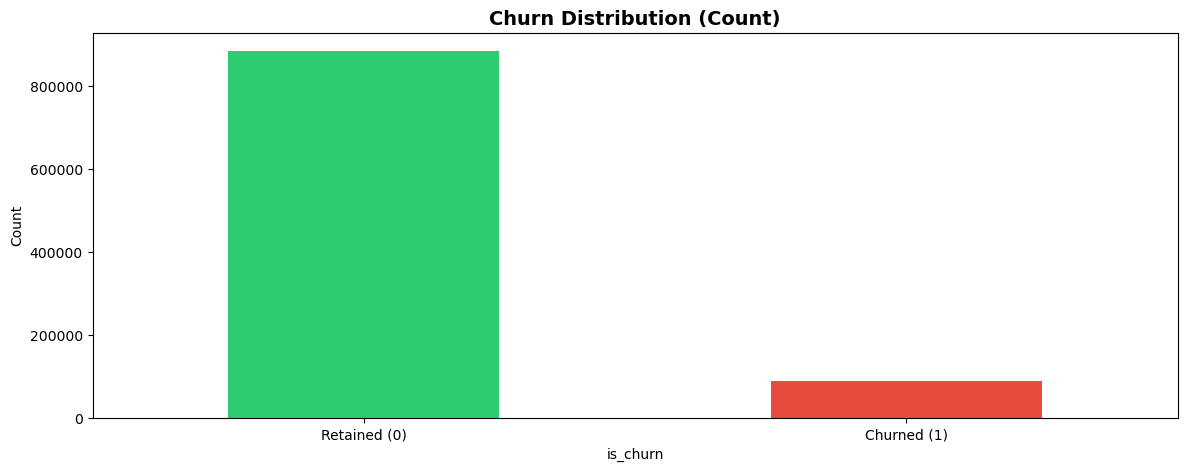

In [38]:
plt.subplots(figsize=(14, 5))
churn_counts.plot(kind='bar',  color=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
plt.xlabel('is_churn')
plt.ylabel('Count')
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'], rotation=0)


In [39]:
retained_count = churn_counts.get(0, 0)
churned_count = churn_counts.get(1, 0)
print("Target Summary:")
print(f"Retained users (0): {retained_count:,}")
print(f"Churned users (1): {churned_count:,}")

if churned_count > 0:
    imbalance_ratio = retained_count / churned_count
    print(f"Majority-to-minority ratio: {imbalance_ratio:.1f}:1")
    
    if imbalance_ratio > 5:
        print("Status: Highly imbalanced ")
    elif imbalance_ratio > 2:
        print("Status: Moderately imbalanced ")
    else:
        print("Status: Fairly balanced")
else:
    print("Status: No churned samples found in the dataset")

Target Summary:
Retained users (0): 883,630
Churned users (1): 87,330
Majority-to-minority ratio: 10.1:1
Status: Highly imbalanced 


3.5.2 Univariate Analysis

c:\Users\sitedirector\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


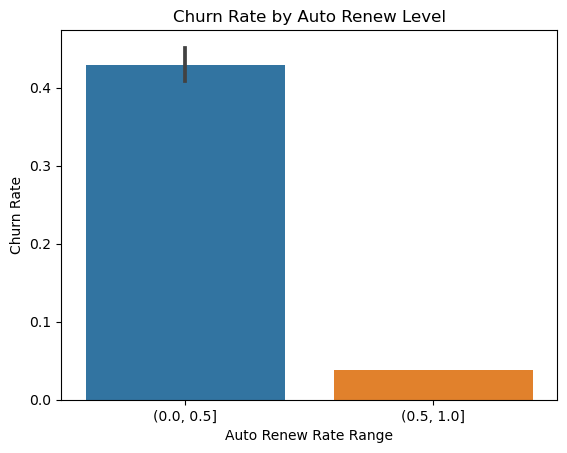

In [ ]:
df['renew_bin'] = pd.cut(df['renewal_frequency'], bins=[0, 0.5, 1])

sns.barplot(
    x='renew_bin',
    y=(df['is_churn'] == 1).astype(int),
    data=df
)
plt.title("Churn Rate by Auto Renew Level")
plt.ylabel("Churn Rate")
plt.xlabel("Auto Renew Rate Range")
plt.show()

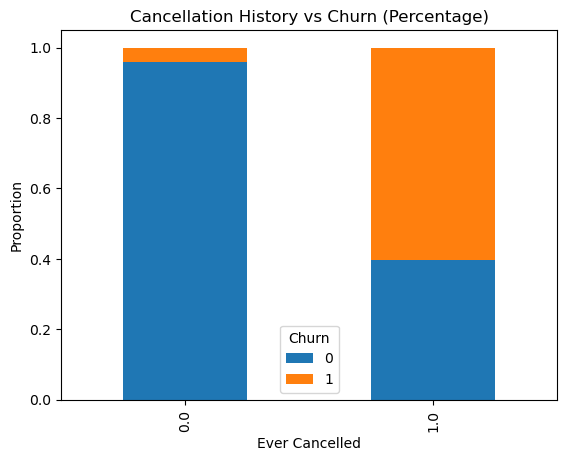

In [44]:
ct = pd.crosstab(df['ever_cancelled'], df['is_churn'], normalize='index')

ct.plot(kind='bar', stacked=True)
plt.title("Cancellation History vs Churn (Percentage)")
plt.ylabel("Proportion")
plt.xlabel("Ever Cancelled")
plt.legend(title="Churn")
plt.show()

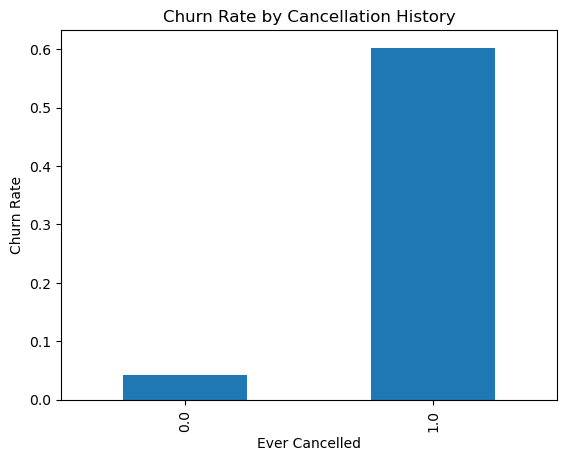

In [45]:
churn_rate = df.groupby('ever_cancelled')['is_churn'].apply(
    lambda x: (x == 1).mean()
)

churn_rate.plot(kind='bar')
plt.title("Churn Rate by Cancellation History")
plt.ylabel("Churn Rate")
plt.xlabel("Ever Cancelled")
plt.show()

c:\Users\sitedirector\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


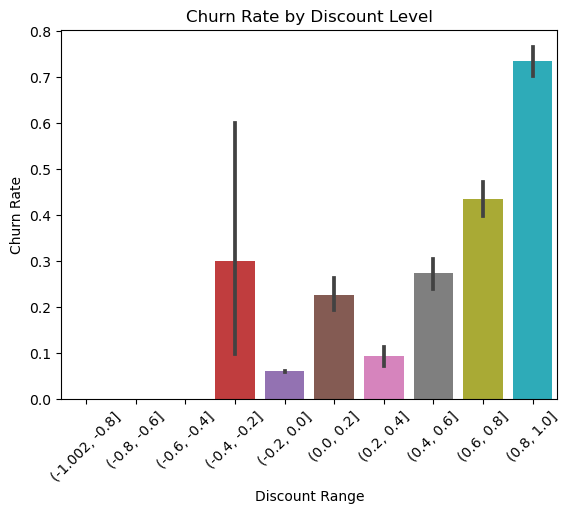

In [47]:
df['discount_bin'] = pd.cut(df['discount_rate'], bins=10)

sns.barplot(
    x='discount_bin',
    y=(df['is_churn'] == 1).astype(int),
    data=df
)

plt.xticks(rotation=45)
plt.title("Churn Rate by Discount Level")
plt.ylabel("Churn Rate")
plt.xlabel("Discount Range")
plt.show()

c:\Users\sitedirector\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


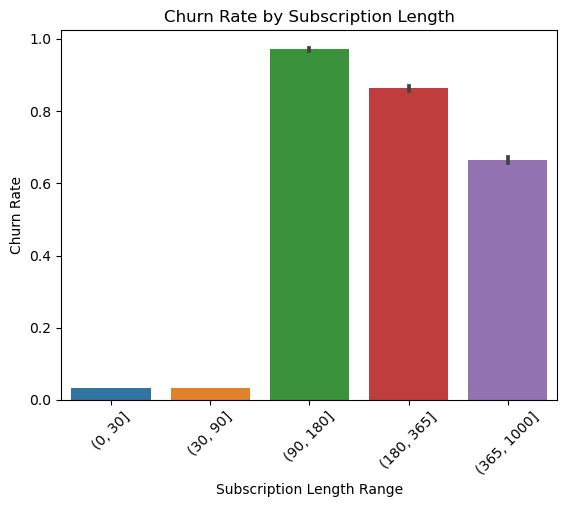

In [55]:
df['sub_bin'] = pd.cut(df['avg_subscription_length'], bins=[0,30,90,180,365,1000])

sns.barplot(
    x='sub_bin',
    y=(df['is_churn'] == 1).astype(int),
    data=df
)

plt.xticks(rotation=45)
plt.title("Churn Rate by Subscription Length")
plt.ylabel("Churn Rate")
plt.xlabel("Subscription Length Range")
plt.show()

c:\Users\sitedirector\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='days_since_last_transaction', ylabel='is_churn'>

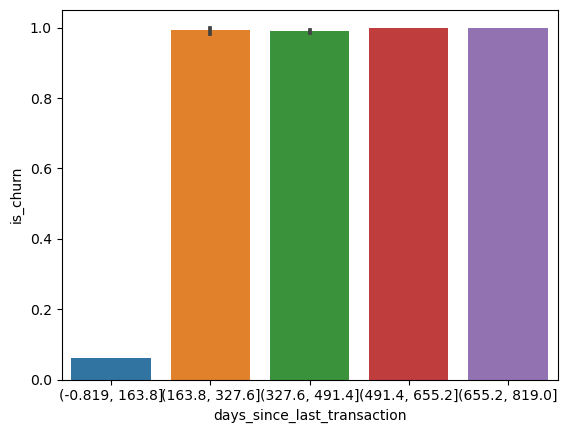

In [77]:
sns.barplot(
    x=pd.cut(df['days_since_last_transaction'], bins=5),
    y=(df['is_churn'] == 1).astype(int),
    data=df
)

3.5.3 Bivariate Analysis

In [56]:
df['is_churn'] = df['is_churn'].map({0: 'No Churn', 1: 'Churn'})

# Convert all categorical features to string
cat_cols = [
    'city_tier',
    'account_age_group',
    'age_group',
    'ever_cancelled'
]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

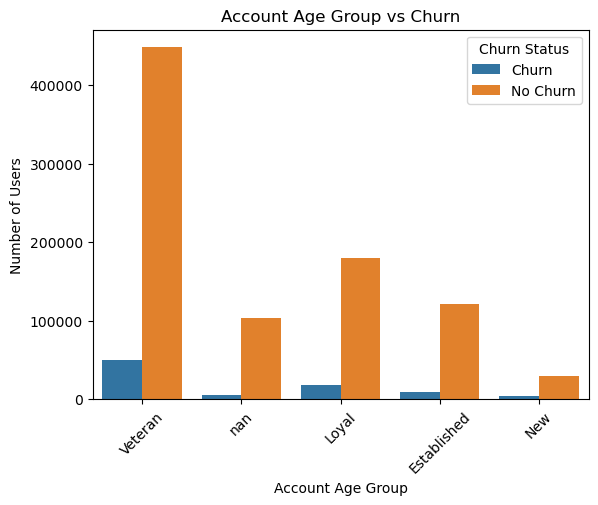

In [57]:
sns.countplot(x='account_age_group', hue='is_churn', data=df)
plt.xticks(rotation=45)
plt.title("Account Age Group vs Churn")
plt.xlabel("Account Age Group")
plt.ylabel("Number of Users")
plt.legend(title="Churn Status")
plt.show()


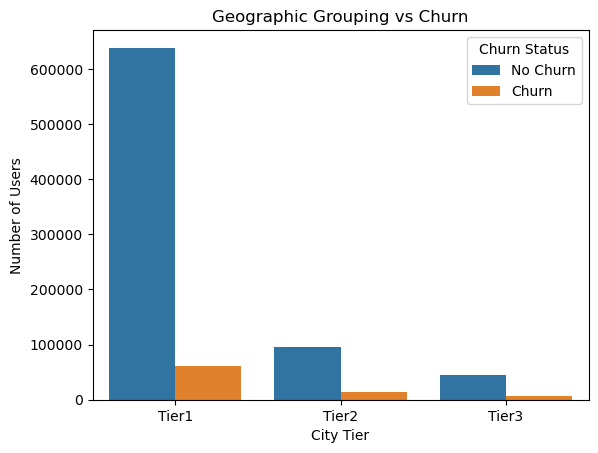

In [58]:

df['city_tier'] = df['city_tier'].astype(str)
df['is_churn'] = df['is_churn'].astype(str)

# Remove bad/missing rows
df = df[
    df['city_tier'].notna() &
    df['is_churn'].notna()
]


sns.countplot(
    x='city_tier',
    hue='is_churn',
    data=df,
    order=['Tier1', 'Tier2', 'Tier3'],
    hue_order=['No Churn', 'Churn']
)

plt.title("Geographic Grouping vs Churn")
plt.xlabel("City Tier")
plt.ylabel("Number of Users")
plt.legend(title="Churn Status")
plt.show()

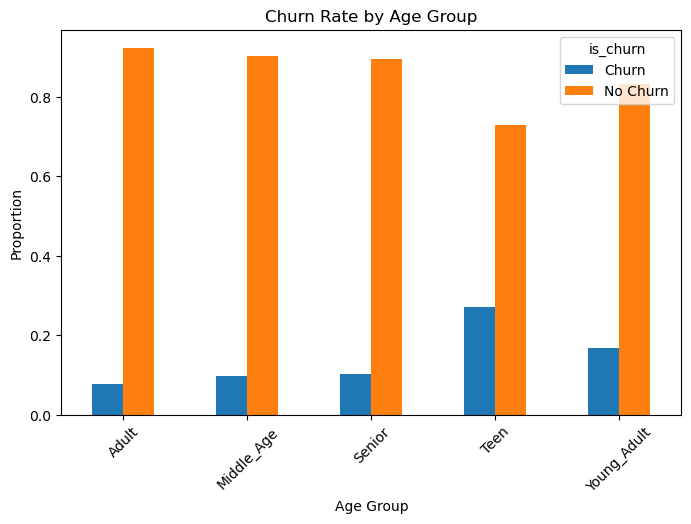

In [59]:
df['age_group'] = df['age_group'].astype(str)
df['is_churn'] = df['is_churn'].astype(str)

df = df[
    ~df['age_group'].isin(['nan', 'None']) &
    ~df['is_churn'].isin(['nan', 'None'])
]

age_props = pd.crosstab(
    df['age_group'],
    df['is_churn'],
    normalize='index'
)

age_props = pd.crosstab(
    df['age_group'],
    df['is_churn'],
    normalize='index'
)

age_props = age_props.fillna(0)

age_props.plot(kind='bar', figsize=(8,5))
plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

3.5.3 Multivariate Analysis

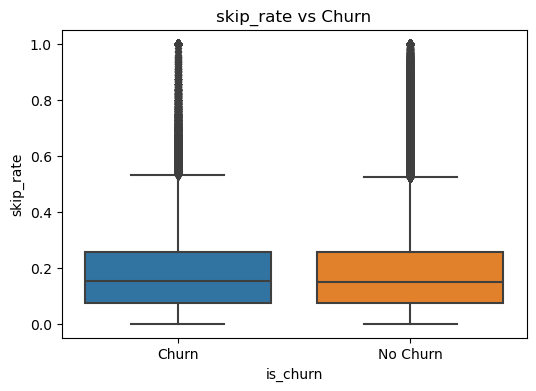

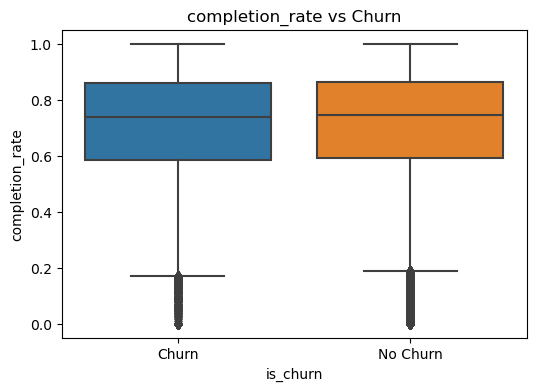

In [62]:
num_cols = ['skip_rate', 'completion_rate']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='is_churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

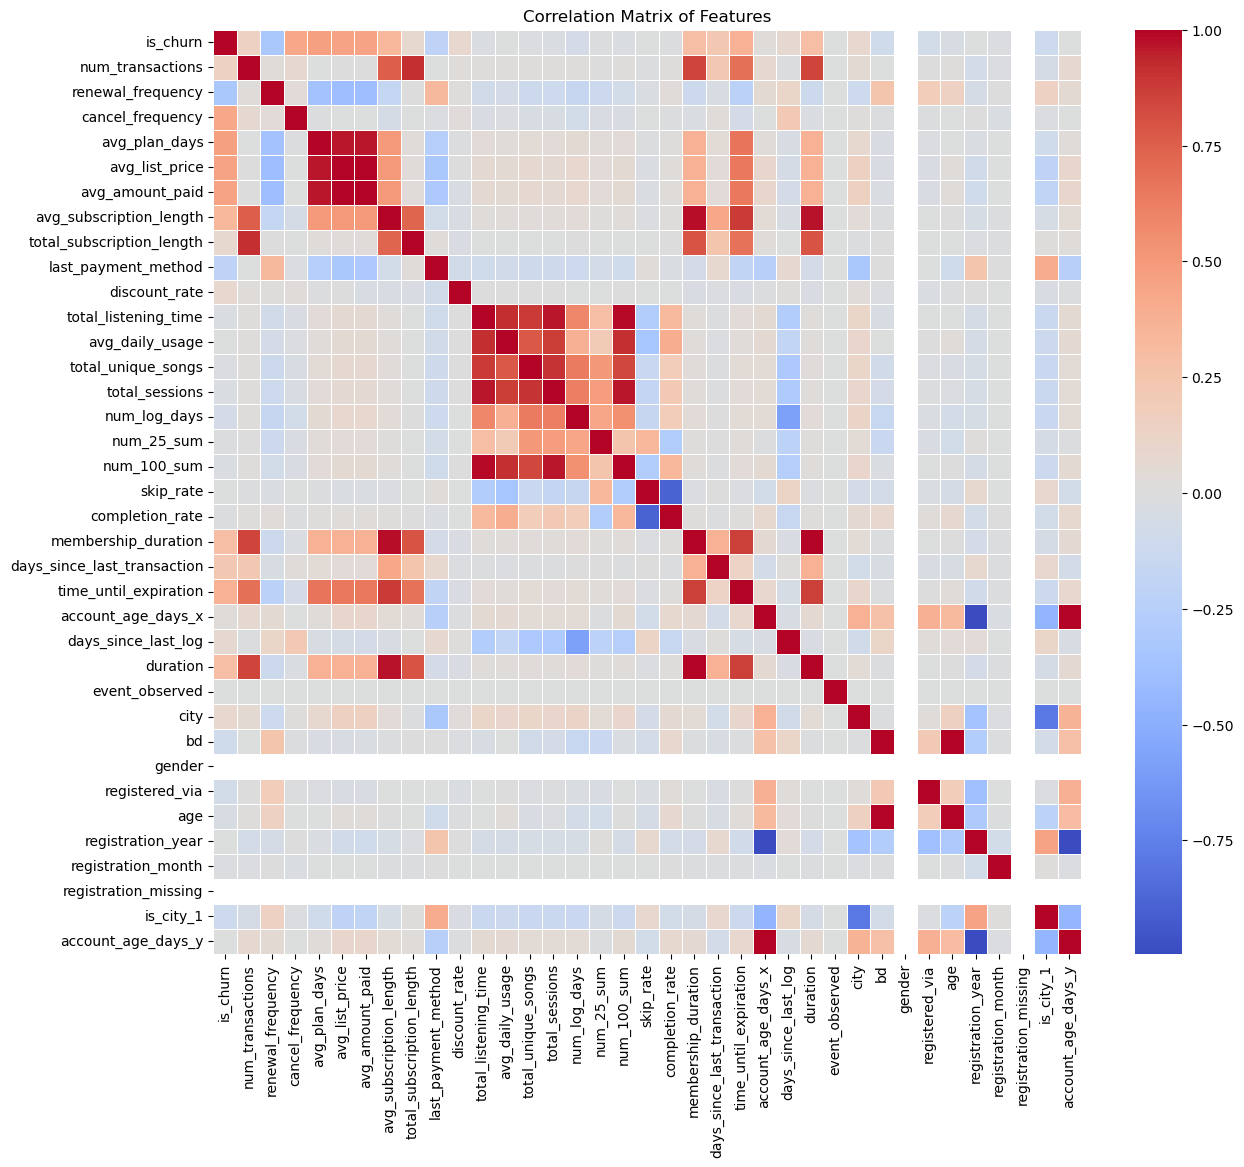

In [71]:
df["is_churn"] = df["is_churn"].map({
    "No Churn": 0,
    "Churn": 1
})

numeric_df = df.select_dtypes(include=["number"])
numeric_df = numeric_df.drop(columns=["msno"], errors="ignore")
corr_matrix = numeric_df.corr()


plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Features")
plt.show()

Text(0.5, 1.0, 'Top 10 Cities by User Count')

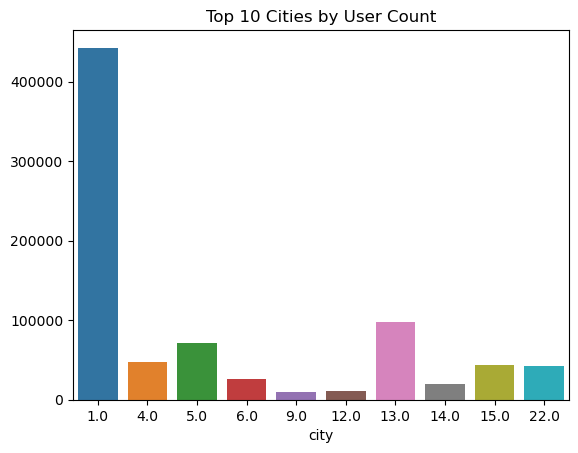

In [74]:
top_cities = df['city'].value_counts().head(10)

sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title("Top 10 Cities by User Count")

Text(0.5, 1.0, 'Top Age Groups')

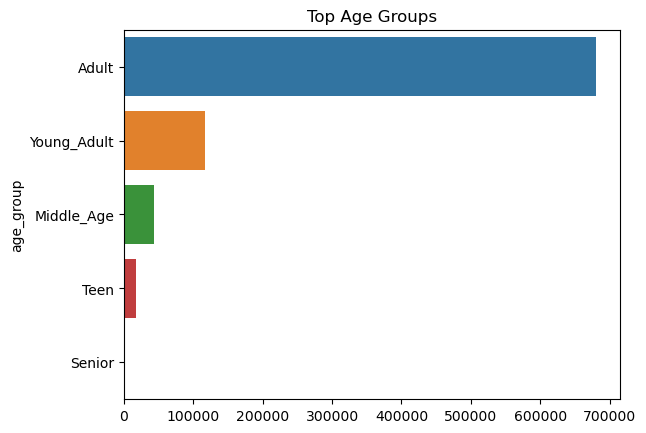

In [75]:
top_age = df['age_group'].value_counts().head(10)

sns.barplot(x=top_age.values, y=top_age.index)
plt.title("Top Age Groups")

## 4. Key Insights

- The target variable `is_churn` is imbalanced, with far fewer churned users than non-churned users. Because of this, accuracy alone is not a reliable evaluation metric.
- User behavior and subscription history appear to be more informative than demographic variables for predicting churn.
- Recency-based features such as `days_since_last_transaction` are likely strong predictors because inactive users are more likely to churn.
- Engagement features such as listening time, daily usage, skip rate, and completion rate can help identify users who are becoming less active.
- Subscription-related variables such as renewal frequency, average subscription length, and cancellation history are likely important indicators of churn risk.
- High-risk group: Customers receiving very large discounts (0.8–1.0) have the highest churn (~75%).Low discount users are more stable: Customers with little or no discount tend to stay longer.

## 5. Avoiding Data Leakage

Data leakage happens when the model uses information that would not have been available at the time the prediction is made. This can cause the model to perform unrealistically well during training and evaluation.

In this project, leakage may occur if features are created using future transactions, future expiration dates, or future user activity. For example, variables such as `last_transaction`, `last_expire`, `last_log_date`, `time_until_expiration`, and `days_since_last_transaction` can leak information if they are calculated using records that occur after the prediction date.

To avoid data leakage:

- Only use data available up to the prediction cutoff date when creating features.
- Define churn using a future label window that begins after the cutoff date.
- Do not allow the feature window and label window to overlap.
- Use time-based train/validation/test splits instead of random splitting.
- Fit preprocessing steps such as scaling, encoding, and imputation on the training set only.
- Exclude features that are directly derived from the target variable or contain future information.

A good rule is: if the value would not have been known at the time of prediction, it should not be used as a feature.